# Final Project-Identifying Key Booking and Customer Factors That Drive Hotel Revenue
Zixuan Li, Sylvie Hu

**1.Data processing and cleaning**

In [ ]:
# ================================
# Setup and Load Data
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the hotel booking dataset
df = pd.read_csv('hotel_bookings.csv')

print("\n📊 Dataset Overview:")
print(f"Total bookings: {len(df)}")
print("\nData types before processing:")
print(df.info())



📊 Dataset Overview:
Total bookings: 119390

Data types before processing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  bab

In [ ]:
# ================================
# Dealing with Missing Values
# ================================

print("Missing values BEFORE cleaning:")
print(df.isnull().sum())

# Business-driven handling of missing values

# children: missing implies no children
df['children'] = df['children'].fillna(0)

# country: missing labeled as 'Unknown'
df['country'] = df['country'].fillna('Unknown')

# agent: missing implies direct booking (set to 0)
df['agent'] = df['agent'].fillna(0)

# company: missing implies non-corporate booking (set to 0)
df['company'] = df['company'].fillna(0)

print("\nMissing values AFTER cleaning:")
print(df.isnull().sum())


Missing values BEFORE cleaning:
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                    

In [ ]:
#Create variable "revenue" by multiplying the average daily rate (adr)
#by the total number of nights stayed. Canceled bookings are assigned zero revenue.
df['total_nights'] = (df['stays_in_week_nights'] + df['stays_in_weekend_nights'])
df['revenue'] = df['adr'] * df['total_nights']
df.loc[df['is_canceled'] == 1, 'revenue'] = 0

#Select relevant features we will focus on for this project
features = [
    'lead_time',
    'customer_type',
    'market_segment',
    'distribution_channel',
    'deposit_type',
    'total_of_special_requests',
    'is_repeated_guest',
    'arrival_date_month'
]


X = df[features]
y = df['revenue']


In [ ]:
# -------------------------------------------------------------
# Identify numeric features among selected predictors
# -------------------------------------------------------------

numeric_features = [
    col for col in features
    if df[col].dtype in ["int64", "float64"]
]

print("Numeric features assessed for outliers:")
print(numeric_features)


Numeric features assessed for outliers:
['lead_time', 'total_of_special_requests', 'is_repeated_guest']


In [ ]:
# -------------------------------------------------------------
# Outlier detection using IQR
# -------------------------------------------------------------

outlier_summary = {}

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = len(outliers)

outlier_summary


{'lead_time': 3005,
 'total_of_special_requests': 2877,
 'is_repeated_guest': 3810}

Using the IQR method, we identified outliers in key numeric features; however, these observations were retained because they represent legitimate booking behaviors (e.g., early planners and high-engagement guests) rather than data quality issues, and are therefore informative for revenue analysis.

In [ ]:
# 1. Convert object columns to 'category'
df['customer_type'] = df['customer_type'].astype('category')
df['market_segment'] = df['market_segment'].astype('category')
df['distribution_channel'] = df['distribution_channel'].astype('category')
df['deposit_type'] = df['deposit_type'].astype('category')
df['arrival_date_month'] = df['arrival_date_month'].astype('category')

# 2. Convert integer columns to smaller int types where appropriate
df['is_repeated_guest'] = df['is_repeated_guest'].astype('int8')
df['total_of_special_requests'] = df['total_of_special_requests'].astype('int8')

# 3. Continuous numerical feature
df['lead_time'] = df['lead_time'].astype('float32')

print("\nData types AFTER cleaning and optimization (final features):")
print(df[features].dtypes)


Data types AFTER cleaning and optimization (final features):
lead_time                     float32
customer_type                category
market_segment               category
distribution_channel         category
deposit_type                 category
total_of_special_requests        int8
is_repeated_guest                int8
arrival_date_month           category
dtype: object


**Comment (Data cleaning,processing, and feature selection):**

We began by examining the dataset for missing values by labeling missing booking channels as non-agent or non-corporate and removing inconsistencies in booking length. We then constructed a booking-level revenue variable using the average daily rate and total nights stayed, assigning zero revenue to canceled bookings to reflect realized revenue.

Next, we selected a subset of features for modeling based on business relevance. Variables directly used to construct revenue were excluded, and the final feature set focused on booking behavior, customer characteristics, channel information, and seasonality that are actionable from a managerial perspective.Outliers in numeric features were retained because they reflect legitimate booking behaviors (e.g., early planners and high-service guests) rather than data quality issues.

Last, we optimized data types to improve computational efficiency. Object variables (e.g., customer type, market segment, distribution channel, deposit type, and arrival month) were converted to the category type, binary indicators (e.g., repeated guest status and special requests) were stored as int8, and continuous variables (e.g., lead time) were converted to float32.


**2.Exploring relationships-Descriptive analysis**

2.1 Univariate analysis for Revenue

In [ ]:
# Revenue summary
print("📊 Revenue Summary:")
df['revenue'].describe()

📊 Revenue Summary:


,revenue
count,119390.000000
mean,217.742360
std,305.807138
min,-63.800000
25%,0.000000
50%,119.000000
75%,323.000000
max,7590.000000


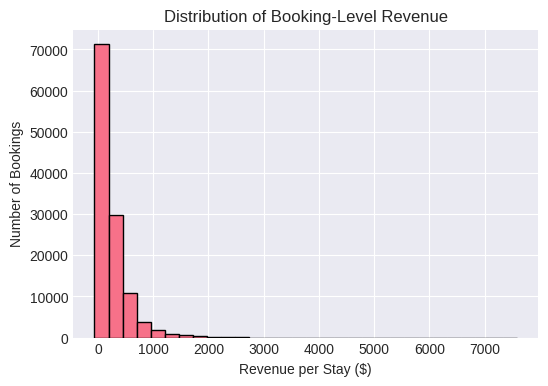

In [ ]:
#Histogram for booking level revenue distribution
plt.figure(figsize=(6,4))
plt.hist(df['revenue'], bins=30, edgecolor='black')
plt.title("Distribution of Booking-Level Revenue")
plt.xlabel("Revenue per Stay ($)")
plt.ylabel("Number of Bookings")
plt.show()


The distribution of revenue per stay is right-skewed, with most bookings generating moderate revenue and a smaller number of high-revenue stays. This pattern reflects heterogeneous booking behavior and motivates the use of regression analysis rather than relying solely on averages.

2.2 Bivariate analysis

2.2.1 Categorical variables

In [ ]:
# Revenue by customer type
customer_revenue = (
    df.groupby('customer_type', observed=False)['revenue']
      .agg(['count', 'mean', 'sum'])
)

customer_revenue.columns = ['Total_Bookings', 'Avg_Revenue', 'Total_Revenue']

print("\n📊 Revenue by Customer Type:")
print(customer_revenue)



📊 Revenue by Customer Type:
                 Total_Bookings  Avg_Revenue  Total_Revenue
customer_type                                              
Contract                   4076   364.307441     1484917.13
Group                       577   213.787002      123355.10
Transient                 89613   215.734737    19332636.95
Transient-Party           25124   201.216018     5055351.23


In [ ]:
#Revenue by market segment
segment_revenue = (
    df.groupby('market_segment', observed=False)['revenue']
      .agg(['count', 'mean', 'sum'])
      .sort_values('mean', ascending=False)
)

segment_revenue.columns = ['Total_Bookings', 'Avg_Revenue', 'Total_Revenue']

print("\n📊 Revenue by Market Segment:")
print(segment_revenue)



📊 Revenue by Market Segment:
                Total_Bookings  Avg_Revenue  Total_Revenue
market_segment                                            
Direct                   12606   325.211690     4099618.57
Aviation                   237   299.022616       70868.36
Online TA                56477   242.831620    13714401.42
Offline TA/TO            24219   233.682422     5659554.58
Corporate                 5295   109.143001      577912.19
Groups                   19811    94.346210     1869092.76
Complementary              743     6.477160        4812.53
Undefined                    2     0.000000           0.00


In [ ]:
#Revenue by Distribution Channel
channel_revenue = (
    df.groupby('distribution_channel', observed=False)['revenue']
      .agg(['count', 'mean', 'sum'])
      .sort_values('mean', ascending=False)
)

channel_revenue.columns = ['Total_Bookings', 'Avg_Revenue', 'Total_Revenue']

print("\n📊 Revenue by Distribution Channel:")
print(channel_revenue)



📊 Revenue by Distribution Channel:
                      Total_Bookings  Avg_Revenue  Total_Revenue
distribution_channel                                            
Direct                         14645   295.339138     4325241.68
TA/TO                          97870   212.624526    20809562.35
GDS                              193   171.025699       33007.96
Corporate                       6677   123.990553      827884.92
Undefined                          5   112.700000         563.50


In [ ]:
#Revenue by Deposit Type
deposit_revenue = (
    df.groupby('deposit_type', observed=False)['revenue']
      .agg(['count', 'mean', 'sum'])
)

deposit_revenue.columns = ['Total_Bookings', 'Avg_Revenue', 'Total_Revenue']

print("\n📊 Revenue by Deposit Type:")
print(deposit_revenue)



📊 Revenue by Deposit Type:
              Total_Bookings  Avg_Revenue  Total_Revenue
deposit_type                                            
No Deposit            104641   247.992310    25950163.33
Non Refund             14587     1.172953       17109.87
Refundable               162   178.933395       28987.21


In [ ]:
#Revenue by Repeated Guest Status
repeat_revenue = (
    df.groupby('is_repeated_guest')['revenue']
      .agg(['count', 'mean', 'sum'])
)

repeat_revenue.columns = ['Total_Bookings', 'Avg_Revenue', 'Total_Revenue']

print("\n📊 Revenue by Repeated Guest Status:")
print(repeat_revenue)



📊 Revenue by Repeated Guest Status:
                   Total_Bookings  Avg_Revenue  Total_Revenue
is_repeated_guest                                            
0                          115580   220.727590    25511694.81
1                            3810   127.182572      484565.60


In [ ]:
#Revenue by Arrival Month (Seasonality)
month_revenue = (
    df.groupby('arrival_date_month', observed=False)['revenue']
      .agg(['count', 'mean', 'sum'])
)

month_revenue.columns = ['Total_Bookings', 'Avg_Revenue', 'Total_Revenue']

print("\n📊 Revenue by Arrival Month:")
print(month_revenue)



📊 Revenue by Arrival Month:
                    Total_Bookings  Avg_Revenue  Total_Revenue
arrival_date_month                                            
April                        11089   189.364008     2099857.48
August                       13877   354.338766     4917159.06
December                      6780   160.382344     1087392.29
February                      8068   142.233699     1147541.48
January                       5929   130.996262      776676.84
July                         12661   323.860443     4100397.07
June                         10939   236.154212     2583290.92
March                         9794   168.684765     1652098.59
May                          11791   203.139143     2395213.64
November                      6794   152.421690     1035552.96
October                      11160   166.381427     1856816.72
September                    10508   223.093201     2344263.36


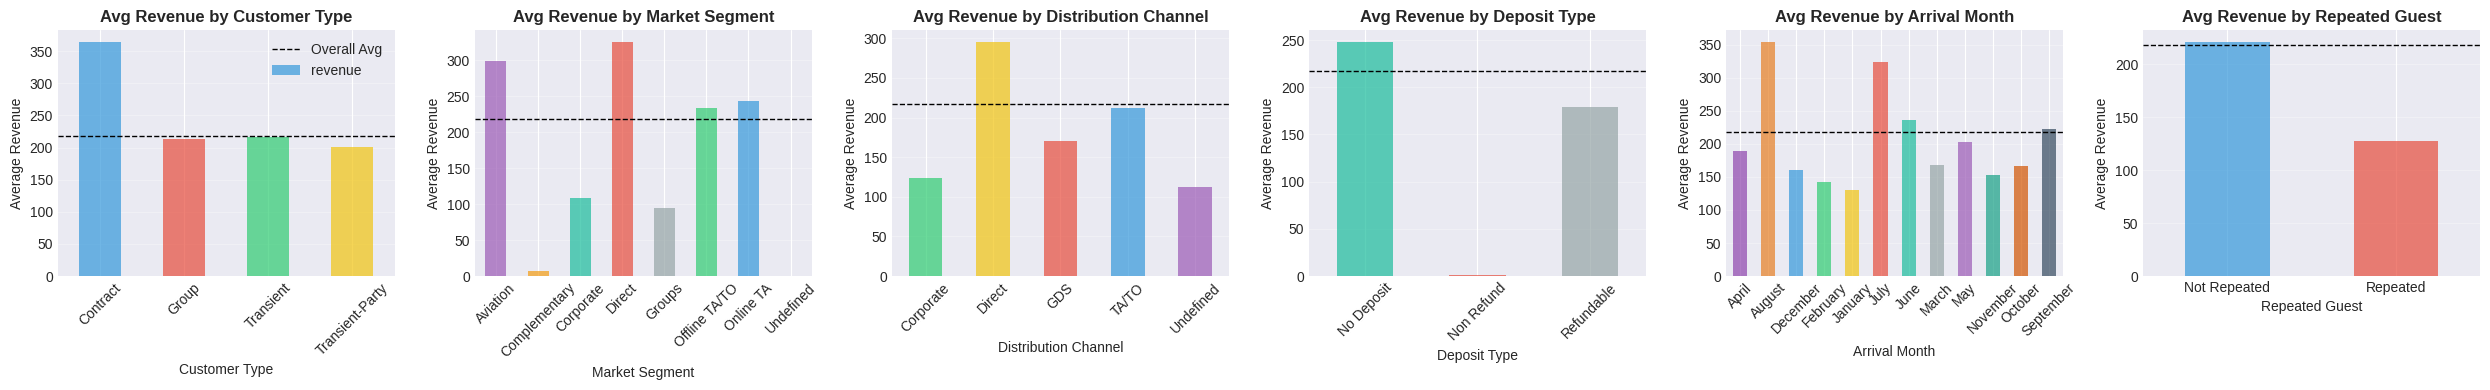

In [ ]:
# Visualization: Average revenue by multiple categorical factors
avg_revenue = df['revenue'].mean()

fig, axes = plt.subplots(1, 6, figsize=(25, 4))

# -------------------------------------------------------------
# 1. Customer Type
# -------------------------------------------------------------
customer_rev = df.groupby('customer_type', observed=False)['revenue'].mean()

customer_rev.plot(kind='bar', ax=axes[0],
                  color=['#3498db', '#e74c3c', '#2ecc71', '#f1c40f'], alpha=0.7)

axes[0].set_title('Avg Revenue by Customer Type', fontweight='bold')
axes[0].set_ylabel('Average Revenue')
axes[0].set_xlabel('Customer Type')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].axhline(avg_revenue, color='black', linestyle='--',
                linewidth=1, label='Overall Avg')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# -------------------------------------------------------------
# 2. Market Segment
# -------------------------------------------------------------
segment_rev = df.groupby('market_segment', observed=False)['revenue'].mean()

segment_rev.plot(kind='bar', ax=axes[1],
                 color=['#9b59b6', '#f39c12', '#1abc9c', '#e74c3c', '#95a5a6',
                        '#2ecc71', '#3498db', '#e67e22'], alpha=0.7)

axes[1].set_title('Avg Revenue by Market Segment', fontweight='bold')
axes[1].set_ylabel('Average Revenue')
axes[1].set_xlabel('Market Segment')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
axes[1].axhline(avg_revenue, color='black', linestyle='--',
                linewidth=1)
axes[1].grid(axis='y', alpha=0.3)

# -------------------------------------------------------------
# 3. Distribution Channel
# -------------------------------------------------------------
channel_rev = df.groupby('distribution_channel', observed=False)['revenue'].mean()

channel_rev.plot(kind='bar', ax=axes[2],
                 color=['#2ecc71', '#f1c40f', '#e74c3c', '#3498db', '#9b59b6'], alpha=0.7)

axes[2].set_title('Avg Revenue by Distribution Channel', fontweight='bold')
axes[2].set_ylabel('Average Revenue')
axes[2].set_xlabel('Distribution Channel')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)
axes[2].axhline(avg_revenue, color='black', linestyle='--',
                linewidth=1)
axes[2].grid(axis='y', alpha=0.3)

# -------------------------------------------------------------
# 4. Deposit Type
# -------------------------------------------------------------
deposit_rev = df.groupby('deposit_type', observed=False)['revenue'].mean()

deposit_rev.plot(kind='bar', ax=axes[3],
                 color=['#1abc9c', '#e74c3c', '#95a5a6'], alpha=0.7)

axes[3].set_title('Avg Revenue by Deposit Type', fontweight='bold')
axes[3].set_ylabel('Average Revenue')
axes[3].set_xlabel('Deposit Type')
axes[3].set_xticklabels(axes[3].get_xticklabels(), rotation=45)
axes[3].axhline(avg_revenue, color='black', linestyle='--',
                linewidth=1)
axes[3].grid(axis='y', alpha=0.3)

# -------------------------------------------------------------
# 5. Arrival Month
# -------------------------------------------------------------
month_rev = df.groupby('arrival_date_month', observed=False)['revenue'].mean()

# 12 colors for 12 months (in case all months appear)
month_colors = ['#8e44ad', '#e67e22', '#3498db', '#2ecc71', '#f1c40f', '#e74c3c',
                '#1abc9c', '#95a5a6', '#9b59b6', '#16a085', '#d35400', '#34495e']

month_rev.plot(kind='bar', ax=axes[4],
               color=month_colors[:len(month_rev)], alpha=0.7)

axes[4].set_title('Avg Revenue by Arrival Month', fontweight='bold')
axes[4].set_ylabel('Average Revenue')
axes[4].set_xlabel('Arrival Month')
axes[4].set_xticklabels(axes[4].get_xticklabels(), rotation=45)
axes[4].axhline(avg_revenue, color='black', linestyle='--',
                linewidth=1)
axes[4].grid(axis='y', alpha=0.3)

# -------------------------------------------------------------
# 6. Repeated Guest
# -------------------------------------------------------------
repeat_rev = df.groupby('is_repeated_guest')['revenue'].mean()

repeat_rev.plot(kind='bar', ax=axes[5],
                color=['#3498db', '#e74c3c'], alpha=0.7)

axes[5].set_title('Avg Revenue by Repeated Guest', fontweight='bold')
axes[5].set_ylabel('Average Revenue')
axes[5].set_xlabel('Repeated Guest')
axes[5].set_xticklabels(['Not Repeated', 'Repeated'], rotation=0)
axes[5].axhline(avg_revenue, color='black', linestyle='--',
                linewidth=1)
axes[5].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


The figures show substantial revenue differences across booking characteristics. Contract customers generate the highest average revenue (about \$360 per stay), compared to Group customers (about \$210), Transient customers (about \$220), and Transient-Party guests (about \$200). Direct bookings outperform other channels at roughly \$300 per stay, while Corporate and GDS channels average closer to \$120 to \$170. No-deposit bookings generate about \$250 per stay, compared to roughly \$180 for refundable bookings and near-zero revenue for non-refundable bookings. Clear seasonality is evident: August and July average around \$350 and \$330 per stay, respectively, while winter months such as January and February average closer to $130 to \$150. Finally, non-repeated guests generate about \$220 per stay, compared to roughly \$130 for repeated guests, highlighting meaningful differences across customer and booking segments.

2.2.2 How numerical variables affect revenue


📊 Correlation Matrix:


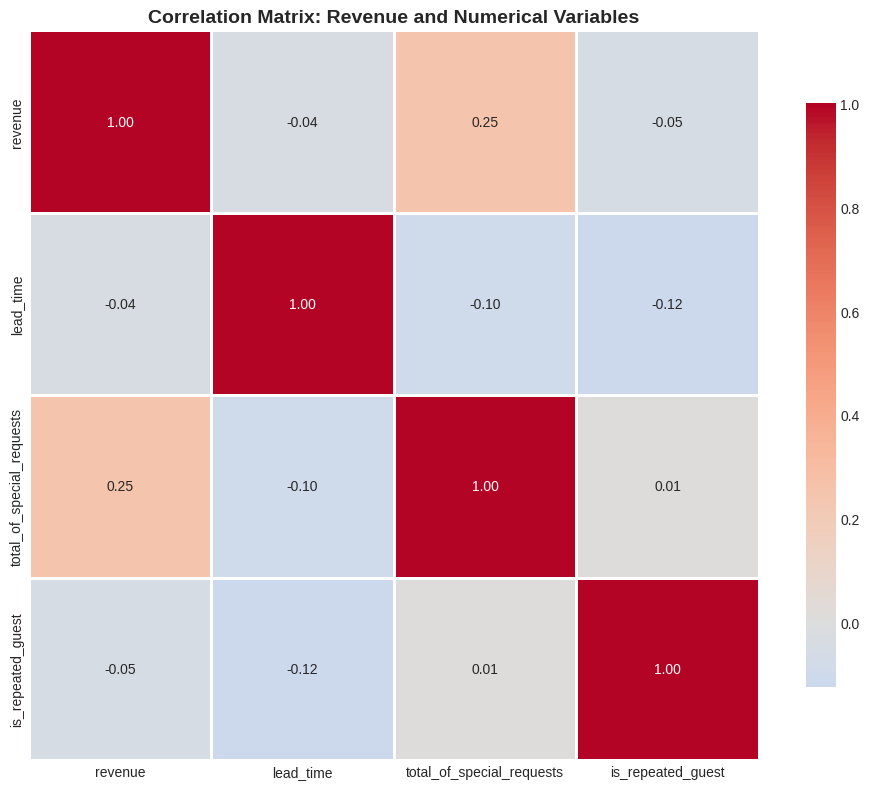

In [ ]:
# Correlation Analysis

# Select numeric columns for correlation
corr_columns = [
    'revenue',
    'lead_time',
    'total_of_special_requests',
    'is_repeated_guest'
]


correlation_matrix = df[corr_columns].corr()

print("\n📊 Correlation Matrix:")

# Visualize correlation
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, square=True,
    linewidths=1, cbar_kws={"shrink": 0.8}
)

plt.title('Correlation Matrix: Revenue and Numerical Variables',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Comment for the correlation matrix:**
The correlation analysis shows that revenue has only weak linear relationships with numerical variables. The strongest association is with total special requests (≈ 0.25), suggesting that guests who request more services tend to generate higher revenue. Lead time and repeated guest status show slight negative correlations with revenue, indicating that early bookings and repeat guests may be associated with discounted rates.

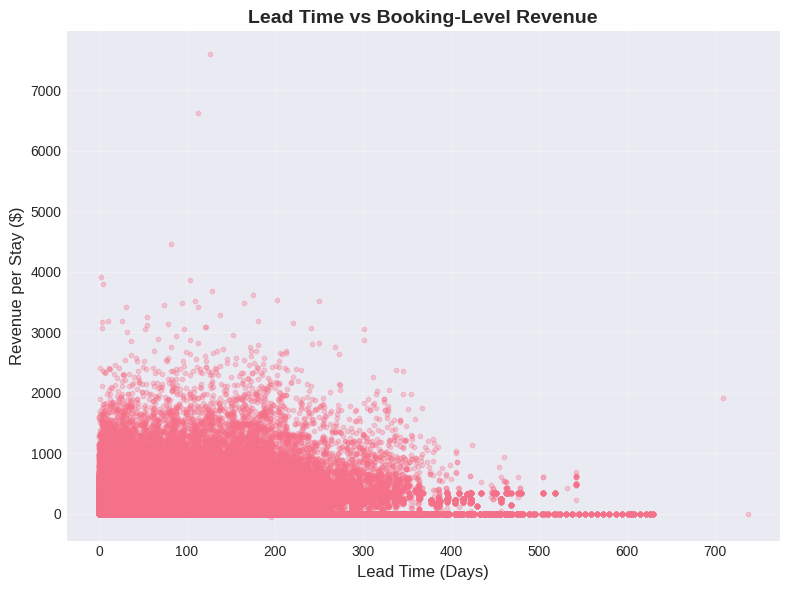

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["lead_time"],
    df["revenue"],
    alpha=0.3,
    s=10
)

plt.xlabel("Lead Time (Days)", fontsize=12)
plt.ylabel("Revenue per Stay ($)", fontsize=12)
plt.title("Lead Time vs Booking-Level Revenue", fontsize=14, fontweight="bold")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


We also include a scatter plot of lead time and booking-level revenue to assess how advance booking behavior relates to revenue outcomes and to validate the direction and dispersion underlying the regression analysis.This pattern suggests that late bookings are associated with higher realized revenue, while early bookings carry greater cancellation risk and lower revenue yield.


**Overall analysis:**
Categorical analysis reveals clearer revenue patterns. Contract and direct bookings generate the highest average revenue per reservation, while transient customers and OTA channels (TA/TO) contribute the largest total revenue due to high booking volume. No-deposit bookings dominate overall revenue, whereas non-refundable bookings generate very low revenue, largely due to cancellations. Strong seasonality is evident, with summer months (July–August) producing the highest revenue. Finally, non-repeated guests generate higher revenue per booking than repeated guests, suggesting a trade-off between loyalty and per-booking profitability.

Overall, these results indicate that revenue is driven more by customer segmentation, booking channel, and seasonality than by individual numerical factors, highlighting the importance of targeted pricing and channel management strategies.

**3.Develop a Multiple Regression Model**

We use linear regression because the target variable (booking-level revenue) is continuous,
and the model allows direct interpretation of how booking characteristics affect expected revenue.


**Interaction Terms Rationale**:

Before doing the regression, two interaction terms are added to capture context-specific effects. The interaction between special requests and peak season reflects that additional requests may generate higher revenue during high-demand months. The interaction between lead time and non-refundable deposits captures that advance bookings can have different revenue implications when pricing flexibility is limited. These interactions help the model better reflect real booking behavior.

In [ ]:
# -------------------------------------------------------------
# Create dummy variables for categorical variables
# -------------------------------------------------------------
df_model = pd.get_dummies(
    df,
    columns=[
        "customer_type",
        "market_segment",
        "distribution_channel",
        "deposit_type",
        "arrival_date_month"
    ],
    drop_first=True,
    dtype=int
)
# ------------------------------------------------------------
# Create interaction term
# ------------------------------------------------------------

# Define peak season (July & August)
df_model["is_peak_season"] = (
    df_model["arrival_date_month_July"] +
    df_model["arrival_date_month_August"]
)

# Interaction:Special requests × Peak season
df_model["special_requests_peak"] = (
    df_model["total_of_special_requests"] * df_model["is_peak_season"]
)

# Interaction: Lead Time × Non-refundable deposit
df_model["leadtime_nonrefund"] = (
    df_model["lead_time"] * df_model["deposit_type_Non Refund"]
)


# -------------------------------------------------------------
# Define response and predictors
# -------------------------------------------------------------
y = df_model["revenue"]

X = df_model[[
    "lead_time",
    "total_of_special_requests",
    "is_repeated_guest",
    "special_requests_peak",
    "leadtime_nonrefund"
] + [col for col in df_model.columns if col.startswith((
    "customer_type_",
    "market_segment_",
    "distribution_channel_",
    "deposit_type_",
    "arrival_date_month_"
))]]

# -------------------------------------------------------------
# Add constant
# -------------------------------------------------------------
X = sm.add_constant(X)

# -------------------------------------------------------------
# Fit linear regression model (OLS)
# -------------------------------------------------------------
reg_model = sm.OLS(y, X).fit()

print(reg_model.summary())


                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.188
Model:                            OLS   Adj. R-squared:                  0.188
Method:                 Least Squares   F-statistic:                     864.1
Date:                Thu, 18 Dec 2025   Prob (F-statistic):               0.00
Time:                        05:15:29   Log-Likelihood:            -8.4023e+05
No. Observations:              119390   AIC:                         1.681e+06
Df Residuals:                  119357   BIC:                         1.681e+06
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [ ]:
#We do the backward elimination
def backward_elimination_ols(X, y, significance_level=0.05):
    """
    Backward elimination for linear regression (OLS).
    Removes the predictor with the highest p-value until all p-values
    are below `significance_level`.
    """
    # list of non-constant features
    features = list(X.columns)
    if 'const' in features:
        features.remove('const')

    X_current = X.copy()
    history = []
    iteration = 0

    while True:
        iteration += 1

        # Fit OLS model
        model = sm.OLS(y, X_current).fit()

        # p-values for non-constant features
        p_values = model.pvalues[features]
        max_p = p_values.max()
        worst_feature = p_values.idxmax()

        # Record progress
        history.append({
            'iteration': iteration,
            'n_features': len(features),
            'max_p_value': float(max_p),
            'worst_feature': worst_feature,
            'adj_r2': float(model.rsquared_adj)
        })

        print(f"\nIteration {iteration}")
        print(f"  Max p-value = {max_p:.4f} (feature: {worst_feature})")
        print(f"  Adj R²      = {model.rsquared_adj:.3f}")

        # Stop when all remaining features are significant
        if max_p <= significance_level:
            print(f"\n✅ All remaining features are significant (p ≤ {significance_level})")
            break

        # Otherwise drop the worst feature and continue
        print(f"  ➜ Dropping '{worst_feature}' from the model")
        X_current = X_current.drop(columns=worst_feature)
        features.remove(worst_feature)

    history_df = pd.DataFrame(history)
    return model, X_current.columns, history_df


In [ ]:
final_model, selected_features, history = backward_elimination_ols(
    X, y, significance_level=0.05
)


Iteration 1
  Max p-value = 0.4937 (feature: distribution_channel_GDS)
  Adj R²      = 0.188
  ➜ Dropping 'distribution_channel_GDS' from the model

Iteration 2
  Max p-value = 0.4152 (feature: distribution_channel_TA/TO)
  Adj R²      = 0.188
  ➜ Dropping 'distribution_channel_TA/TO' from the model

Iteration 3
  Max p-value = 0.2210 (feature: market_segment_Undefined)
  Adj R²      = 0.188
  ➜ Dropping 'market_segment_Undefined' from the model

Iteration 4
  Max p-value = 0.2141 (feature: deposit_type_Refundable)
  Adj R²      = 0.188
  ➜ Dropping 'deposit_type_Refundable' from the model

Iteration 5
  Max p-value = 0.0138 (feature: arrival_date_month_May)
  Adj R²      = 0.188

✅ All remaining features are significant (p ≤ 0.05)


We applied a backward elimination approach to refine the linear regression model. Starting from the full specification, predictors with the highest p-values were iteratively removed until all remaining variables were statistically significant at the 5% level. Throughout this process, adjusted R² remained stable (≈ 0.188), indicating that the reduced model achieves similar explanatory power with fewer predictors. Therefore, we select the final model for its improved parsimony and interpretability without loss of performance.

In [ ]:
print("\n===== FINAL MODEL SUMMARY =====")
print(final_model.summary())

print("\n===== SELECTED FEATURES =====")
print(list(selected_features))

print("\n===== BACKWARD ELIMINATION HISTORY =====")
print(history)


===== FINAL MODEL SUMMARY =====
                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.188
Model:                            OLS   Adj. R-squared:                  0.188
Method:                 Least Squares   F-statistic:                     987.3
Date:                Wed, 17 Dec 2025   Prob (F-statistic):               0.00
Time:                        12:48:19   Log-Likelihood:            -8.4023e+05
No. Observations:              119390   AIC:                         1.681e+06
Df Residuals:                  119361   BIC:                         1.681e+06
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

**Interpretation of the Final Linear Regression Model**

This OLS regression models booking revenue as a function of booking characteristics, guest type, channel, deposit type, and arrival month. All coefficients are interpreted relative to their reference categories, holding other variables constant.

**Key Continuous Predictors**

Lead time has a small but statistically significant positive effect: bookings made further in advance are associated with slightly higher revenue.

Special requests significantly increase revenue, with a baseline effect of about 59 dollars per request. Importantly, this effect is amplified during peak summer months, where each additional request generates roughly $133 in total, highlighting stronger upselling opportunities during high-demand periods.

Repeated guests generate substantially less revenue: repeat bookings earn about $85 less per stay on average than first-time guests (p < 0.001), likely reflecting loyalty discounts or different booking patterns.

**Customer Type (relative to Contract customers)**

Group bookings generate about $129 less per stay.

Transient bookings generate about $107 less.

Transient-Party bookings generate the least, about $142 less per booking.

This suggests that contract customers are more valuable on a per-booking basis, and that pricing, upselling, or minimum-stay strategies could be used to improve revenue from transient and group segments.

**Market Segment Effects(relative to the Aviation segment)**

Complementary bookings reduce revenue by about $374, the largest negative effect, consistent with free or heavily discounted stays.

Corporate bookings earn about 157 less, and Online TA bookings earn about 149 less, compared to the reference segment.

Direct bookings generate about $79 less.

Group bookings generate about $112 less.

Offline TA/TO bookings generate about $57 less.

Aviation bookings are the highest-revenue segment. Large revenue shortfalls from complementary and online travel agent segments suggest these channels are primarily volume-driven rather than value-driven, and should be used strategically to fill capacity rather than maximize revenue per booking.

**Distribution Channel (relative to Corporate bookings)**

Direct bookings generate about $48 more per stay.

Direct bookings outperform corporate bookings in revenue per stay, indicating strong incentives for the hotel to encourage direct reservations through loyalty programs or website promotions.

**Deposit Type (relative to No-Deposit bookings)**

Non-refundable bookings are associated with approximately $226 lower revenue per stay, holding other factors constant. While non-refundable deposits provide revenue certainty, they appear to attract more price-sensitive customers and limit upside potential, particularly during high-demand periods when engaged guests (e.g., those making special requests) generate substantially higher revenue. This suggests that strict deposit policies may reduce per-stay revenue by constraining high-value bookings during peak season.

**Arrival Month (relative to April)**

August and July bookings generate \$71 and \$47 more per stay, respectively. Winter months such as January, February, December, and November generate significantly lower revenue.

The interaction between special requests and peak season suggests that guest engagement is especially valuable during summer months, when demand is high and customers are more willing to pay for add-on services.

Revenue is strongly seasonal, with peak summer months driving higher per-stay revenue. Pricing and capacity management strategies should capitalize on summer demand while using promotions or discounts to stimulate bookings during low-revenue winter months.

**Summary for the model**

**Strongest predictor**:
Total number of special requests remains the strongest driver of revenue. Outside of peak season, each additional special request increases revenue by approximately 59 dollars per stay, while during peak season the interaction term adds an additional 74 dollars per request, implying a combined effect of roughly 133 dollars per request in peak months.

**Second strongest predictor**:
Arrival month (seasonality) continues to play a major role. Relative to April, August (+71 dollars) and July (+47 dollars) generate significantly higher per-stay revenue, while winter months such as January, February, December, and November are associated with substantially lower revenue.

**Negative predictors**:
Repeated guest status is associated with about $85 lower revenue per stay relative to first-time guests, likely reflecting loyalty discounts or different booking behaviors.

Non-refundable deposit type is associated with approximately $226 lower revenue per stay relative to no-deposit bookings, suggesting that stricter deposit policies attract more price-sensitive customers and limit upside revenue.

Customer type effects show that Group, Transient, and Transient-Party bookings generate roughly \$107–$142 less per stay compared to Contract customers, indicating that contract customers are the highest-value segment on a per-booking basis.

Channel effects:
Direct distribution channels generate approximately $48 more revenue per stay relative to the reference channel, while intermediary channels such as TA/TO reduce revenue, highlighting the margin advantage of direct bookings.

The final linear regression model shows that per-stay revenue is primarily driven by booking characteristics, customer segmentation, seasonality, and booking flexibility. The number of special requests has the strongest positive effect, indicating that guests requesting more services tend to generate substantially higher revenue per stay. Revenue is also highly seasonal, with peak summer months (especially July and August) generating significantly more revenue than April, while winter months are associated with lower revenue. In contrast, repeated guests, non-refundable deposits, and non-contract customer types are linked to lower per-stay revenue, suggesting greater price sensitivity or discounted booking patterns, while direct bookings outperform intermediary channels. Variables removed during backward elimination did not add meaningful explanatory power, leaving an interpretable model that captures the main structural drivers of revenue.

**4.Make prediction based on the model**

In [ ]:
# Make predictions
X_final = X[selected_features]
y_pred = final_model.predict(X_final)

# Metrics
r2 = final_model.rsquared
rmse = final_model.resid.std()

print("\n💡 MULTIPLE REGRESSION RESULTS:")
print(f"  Intercept (b0): ${final_model.params.iloc[0]:.2f}")

# Print only top 15 coefficients by absolute value (excluding intercept)
top_params = final_model.params.drop('const', errors='ignore').abs().sort_values(ascending=False).head(15).index
for col in top_params:
    print(f"  Coefficient for {col}: {final_model.params[col]:.3f}")

print("\n MODEL PERFORMANCE:")
print(f"  R²    = {r2:.4f}")
print(f"  RMSE  = ${rmse:.2f}")



💡 MULTIPLE REGRESSION RESULTS:
  Intercept (b0): $420.35
  Coefficient for market_segment_Complementary: -373.160
  Coefficient for distribution_channel_Undefined: -363.455
  Coefficient for deposit_type_Non Refund: -202.255
  Coefficient for market_segment_Corporate: -158.401
  Coefficient for market_segment_Online TA: -151.012
  Coefficient for customer_type_Transient-Party: -144.298
  Coefficient for customer_type_Group: -129.701
  Coefficient for market_segment_Groups: -114.273
  Coefficient for customer_type_Transient: -108.193
  Coefficient for is_repeated_guest: -84.127
  Coefficient for market_segment_Direct: -78.524
  Coefficient for special_requests_peak: 74.003
  Coefficient for arrival_date_month_August: 71.867
  Coefficient for arrival_date_month_January: -63.851
  Coefficient for market_segment_Offline TA/TO: -60.434

 MODEL PERFORMANCE:
  R²    = 0.1881
  RMSE  = $275.56


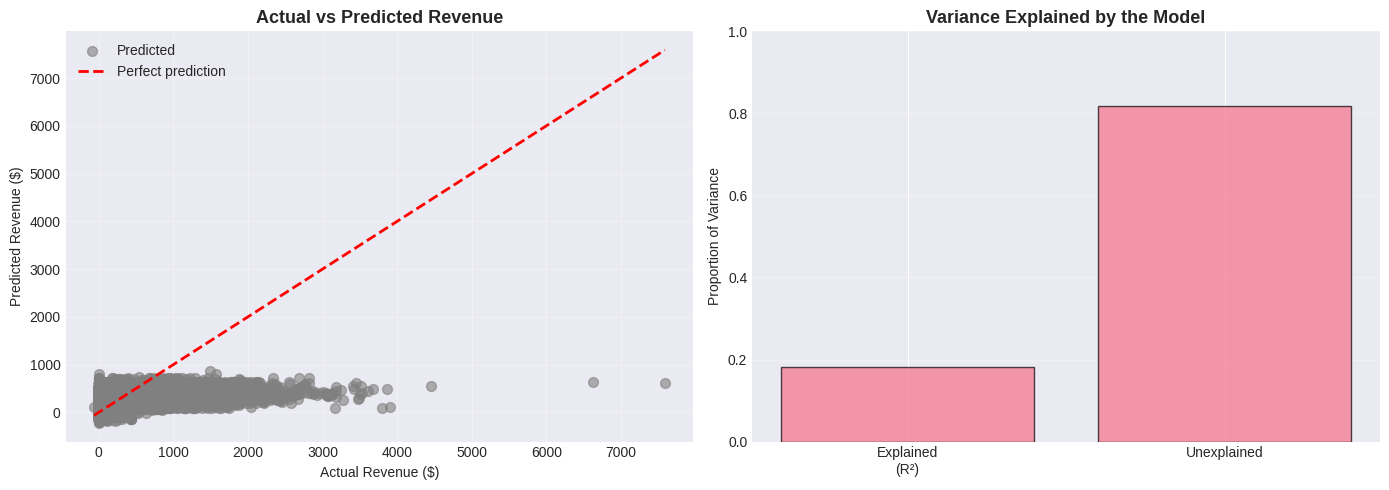

In [ ]:
# Visualize actual vs predicted revenue and variance explained
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Plot 1: Actual vs Predicted Revenue ----
axes[0].scatter(y, y_pred, alpha=0.6, s=50, color="gray", label="Predicted")
axes[0].plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    "r--",
    linewidth=2,
    label="Perfect prediction"
)
axes[0].set_xlabel("Actual Revenue ($)")
axes[0].set_ylabel("Predicted Revenue ($)")
axes[0].set_title("Actual vs Predicted Revenue", fontweight="bold", fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---- Plot 2: R² vs Unexplained Variance ----
explained = r2
unexplained = 1 - r2

labels = ["Explained\n(R²)", "Unexplained"]
values = [explained, unexplained]

axes[1].bar(labels, values, alpha=0.7, edgecolor="black")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Proportion of Variance")
axes[1].set_title("Variance Explained by the Model", fontweight="bold", fontsize=13)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


In [ ]:
# Comment on the model’s predictive power
if r2 > 0.7:
    comment = "The model has strong predictive power."
elif r2 > 0.4:
    comment = "The model has moderate predictive power, capturing main patterns but leaving room for improvement."
else:
    comment = (
        "The model has weak predictive power, which is expected for individual-level revenue data. "
        "While predictive accuracy is limited, the model remains useful for identifying statistically "
        "significant drivers and directional effects on revenue."
    )

print(f"\n COMMENT: {comment}")



 COMMENT: The model has weak predictive power, which is expected for individual-level revenue data. While predictive accuracy is limited, the model remains useful for identifying statistically significant drivers and directional effects on revenue.


In [ ]:
#Evaluating the train–test split
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X[selected_features], y, test_size=0.2, random_state=42
)

model = final_model
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

rmse, r2


(np.float64(279.36289720787147), 0.19421332601514596)

Using an 80/20 train–test split, the linear regression model achieves an RMSE of approximately $279, indicating that predictions deviate from actual booking-level revenue by about \$279 per stay on average. The out-of-sample R² of 0.19 suggests that while the model captures meaningful structural drivers of revenue (such as seasonality, booking behavior, and channel effects), a substantial portion of revenue variation remains unexplained, which is expected given demand uncertainty and unobserved guest-level factors. Overall, the model is more suitable for directional insights and managerial decision-making than for precise revenue prediction at the individual booking level.

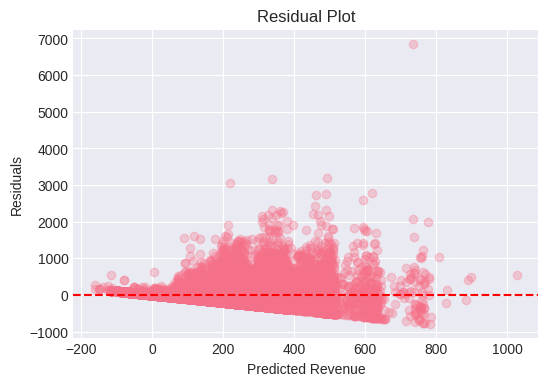

In [ ]:
#Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Revenue")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


The residuals are centered around zero with no strong systematic pattern, supporting the linear model assumptions while indicating some heteroskedasticity at higher revenue levels.

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

# Define model
lr = LinearRegression()

# 5-fold cross-validation on selected features
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = -cross_val_score(
    lr,
    X[selected_features],
    y,
    scoring="neg_root_mean_squared_error",
    cv=kf
)

r2_scores = cross_val_score(
    lr,
    X[selected_features],
    y,
    scoring="r2",
    cv=kf
)

rmse_scores.mean(), r2_scores.mean()


(np.float64(275.59197311340444), np.float64(0.18767200939263315))

We further evaluate model stability using 5-fold cross-validation. The average RMSE (≈ $276) and R² (≈ 0.19) are consistent with the hold-out test results, indicating stable out-of-sample performance.

**Insight:**
Overall, while the model’s predictive power is limited (R² ≈ 0.18), this result is expected given the high variability and heterogeneity in individual booking-level revenue(also given the large dataset).Although the model only explains 18% of the variance, this level of explanatory power is common in large-scale transactional datasets where individual behavior is influenced by many unobserved factors. Rather than serving as a precise forecasting tool, the regression model is most valuable for identifying and quantifying the key structural drivers of revenue, such as customer characteristics, booking behavior, seasonality, and channel effects. The findings provide meaningful managerial insights into which factors systematically increase or decrease per-stay revenue, even if a substantial portion of revenue variation remains unexplained.


**Recommendations:**
To boost hotel booking revenue, we suggest that the hotels:

**Actively upsell special requests**, especially during peak season (July–August), since each additional request significantly increases revenue and has an even stronger impact in high-demand months.

**Design premium add-on bundles for summer stays**(e.g., room upgrades, amenities, experiences), as peak-season bookings yield substantially higher per-stay revenue.

**Re-evaluate non-refundable deposit policies**, as these bookings are associated with lower revenue per stay; consider pairing non-refundable rates with minimum-stay requirements or bundled services to offset revenue loss.

**Encourage direct bookings** through loyalty incentives, website promotions, and member-only perks, since direct channels outperform intermediary channels in revenue per stay.

**Differentiate pricing strategies by customer type**: contract customers are the highest-value segment, while transient and group customers may require targeted upselling or pricing floors to improve per-stay revenue.

**Use intermediaries strategically**, particularly online and offline travel agents, to fill capacity during low-demand periods rather than relying on them during peak revenue opportunities.

**Leverage seasonality in revenue management**, raising prices and limiting discounts during summer months while using targeted promotions to stimulate demand in lower-revenue winter months.

**Monitor repeated guests’ booking behavior**, as repeat bookings are associated with lower revenue; adjust loyalty programs to encourage upgrades rather than discounts alone.

5.Exploration of additional models

In [ ]:
# =============================================================
# Decision Tree Regressor (fit on TRAIN only)
# =============================================================

from sklearn.tree import DecisionTreeRegressor
# 1. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X[selected_features], y, test_size=0.2, random_state=42
)

print("\n📊 DATA SPLIT SUMMARY:")
print(f"  Total samples: {len(y)}")
print(f"  Training set: {len(y_train)} samples ({len(y_train)/len(y):.0%})")
print(f"  Test set:     {len(y_test)} samples ({len(y_test)/len(y):.0%})")

# (Optional) revenue "rate" equivalent: average revenue in each split
print("\n🔍 Target Summary (Avg Revenue):")
print(f"  Train avg revenue: {y_train.mean():.2f}")
print(f"  Test avg revenue:  {y_test.mean():.2f}")

# 2. Decision Tree Regressor (fit on TRAIN only)
dt_model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=50,
    random_state=42
)
dt_model.fit(X_train, y_train)

# 3. Predict on the TEST set
y_pred_dt = dt_model.predict(X_test)

# 4. Evaluate on TEST set
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("\n📈 Performance on TEST set:")
print(f"  RMSE: {rmse_dt:.3f}")
print(f"  R²:   {r2_dt:.3f}")

# 5. Feature importance
feature_importance_dt = pd.DataFrame({
    "feature": X_train.columns,
    "importance": dt_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nFeature importance (Decision Tree):")
print(feature_importance_dt)



📊 DATA SPLIT SUMMARY:
  Total samples: 119390
  Training set: 95512 samples (80%)
  Test set:     23878 samples (20%)

🔍 Target Summary (Avg Revenue):
  Train avg revenue: 217.84
  Test avg revenue:  217.35

📈 Performance on TEST set:
  RMSE: 279.498
  R²:   0.193

Feature importance (Decision Tree):
                           feature    importance
4            special_requests_peak  4.045633e-01
17         deposit_type_Non Refund  2.921310e-01
11           market_segment_Direct  1.010163e-01
1                        lead_time  9.517263e-02
2        total_of_special_requests  4.201252e-02
13    market_segment_Offline TA/TO  1.849363e-02
8    customer_type_Transient-Party  1.735229e-02
14        market_segment_Online TA  1.162502e-02
3                is_repeated_guest  7.119363e-03
7          customer_type_Transient  6.808705e-03
22         arrival_date_month_July  3.149722e-03
9     market_segment_Complementary  5.553647e-04
5               leadtime_nonrefund  1.825877e-07
12         

**Comparing the decision tree to the baseline model:**

The baseline model in our analysis is a linear regression predicting booking-level revenue. Using an 80/20 train–test split, the baseline achieves a test RMSE of 279.50 and an R² of 0.194, with nearly identical average revenue in the training and test sets (217.84 vs. 217.35), indicating a well-balanced split.

To assess model stability, we further evaluate the same linear regression using 5-fold cross-validation, yielding an average RMSE of 275.59 and an average R² of 0.188. These results are highly consistent with the hold-out test performance, suggesting that the baseline model generalizes reliably and is not sensitive to a particular data split.

To test an alternative model, we further implement a decision tree model as a non-linear approach and evaluate it on the same test set for direct comparison. The decision tree achieves a test RMSE of 279.50 and an R² of 0.193, which is nearly identical to the baseline linear regression. While the decision tree does not provide a meaningful improvement in predictive performance, it offers additional interpretability by highlighting key revenue drivers such as peak special requests, non-refundable deposit types, direct market segments, and lead time.

Overall, the linear regression remains the preferred predictive model due to its comparable performance, greater stability, and simpler structure, while the decision tree serves as a complementary tool for identifying non-linear feature importance.